Caso queira ver o modelo pelo Google colab aqui está o link: https://colab.research.google.com/drive/1xpFVLHsO5y_qsUl4Fd-XziYmIIESJ8c3?usp=sharing

## DATA UNDERSTANDING

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [10]:
df = pd.read_csv("../data/crop_yield.csv")


### EDA - Análise Exploratória de Dados

In [11]:
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [12]:
df.columns.tolist()

['Region',
 'Soil_Type',
 'Crop',
 'Rainfall_mm',
 'Temperature_Celsius',
 'Fertilizer_Used',
 'Irrigation_Used',
 'Weather_Condition',
 'Days_to_Harvest',
 'Yield_tons_per_hectare']

In [13]:
df.dtypes

Region                     object
Soil_Type                  object
Crop                       object
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition          object
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

In [14]:
df.shape

(1000000, 10)

In [15]:
df['Region'].value_counts()

Region
North    250173
West     250074
South    250054
East     249699
Name: count, dtype: int64

In [16]:
df['Soil_Type'].value_counts()

Soil_Type
Sandy     167119
Loam      166795
Chalky    166779
Silt      166672
Clay      166352
Peaty     166283
Name: count, dtype: int64

In [17]:
df['Crop'].value_counts()

Crop
Maize      166824
Rice       166792
Barley     166777
Wheat      166673
Cotton     166585
Soybean    166349
Name: count, dtype: int64

In [18]:
df['Weather_Condition'].value_counts()

Weather_Condition
Sunny     333790
Rainy     333561
Cloudy    332649
Name: count, dtype: int64

In [19]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [20]:
df.describe(include='object')

,Region,Soil_Type,Crop,Weather_Condition
count,1000000,1000000,1000000,1000000
unique,4,6,6,3
top,North,Sandy,Maize,Sunny
freq,250173,167119,166824,333790


#OneHotEncoder


In [21]:
colunas_alvo = ['Fertilizer_Used', 'Irrigation_Used']
df[colunas_alvo] = df[colunas_alvo].astype(int)
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,0,1,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,1,1,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,0,0,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,0,1,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,1,1,Cloudy,110,7.248251


### Qualidade dos Dados

In [22]:
df.isnull().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

In [23]:
df.isna().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

In [24]:
print(df["Region"].unique())
print(df["Soil_Type"].unique())
print(df["Crop"].unique())
print(df["Weather_Condition"].unique())

['West' 'South' 'North' 'East']
['Sandy' 'Clay' 'Loam' 'Silt' 'Peaty' 'Chalky']
['Cotton' 'Rice' 'Barley' 'Soybean' 'Wheat' 'Maize']
['Cloudy' 'Rainy' 'Sunny']


In [25]:
df.dtypes

Region                     object
Soil_Type                  object
Crop                       object
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used             int64
Irrigation_Used             int64
Weather_Condition          object
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

#Gráficos


In [26]:
import plotly.express as px
import plotly.graph_objects as go
!pip install squarify

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Gráfico de Barras: Rendimento Médio por Tipo de Cultura

Este gráfico é útil para comparar o rendimento médio (Yield_tons_per_hectare) entre diferentes tipos de culturas (Crop). Ele nos permite identificar quais culturas são mais produtivas em média.

C:\Users\igorp\AppData\Local\Temp\ipykernel_15720\1810153624.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Crop', y='Yield_tons_per_hectare', data=avg_yield_by_crop, palette='viridis')


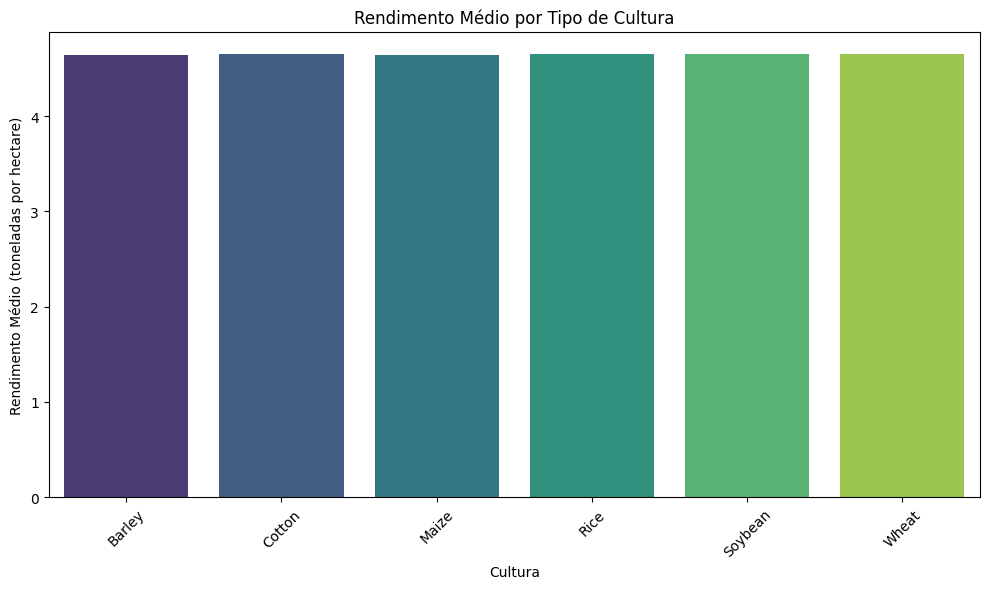

In [27]:
avg_yield_by_crop = df.groupby('Crop')['Yield_tons_per_hectare'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Crop', y='Yield_tons_per_hectare', data=avg_yield_by_crop, palette='viridis')
plt.title('Rendimento Médio por Tipo de Cultura')
plt.xlabel('Cultura')
plt.ylabel('Rendimento Médio (toneladas por hectare)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Gráfico de Linhas: Rendimento Médio ao longo dos Dias para Colheita

Embora não tenhamos uma série temporal explícita, podemos observar a tendência do rendimento médio em relação aos 'Days_to_Harvest'. Isso pode indicar se culturas que demoram mais ou menos para colher tendem a ter um rendimento maior.

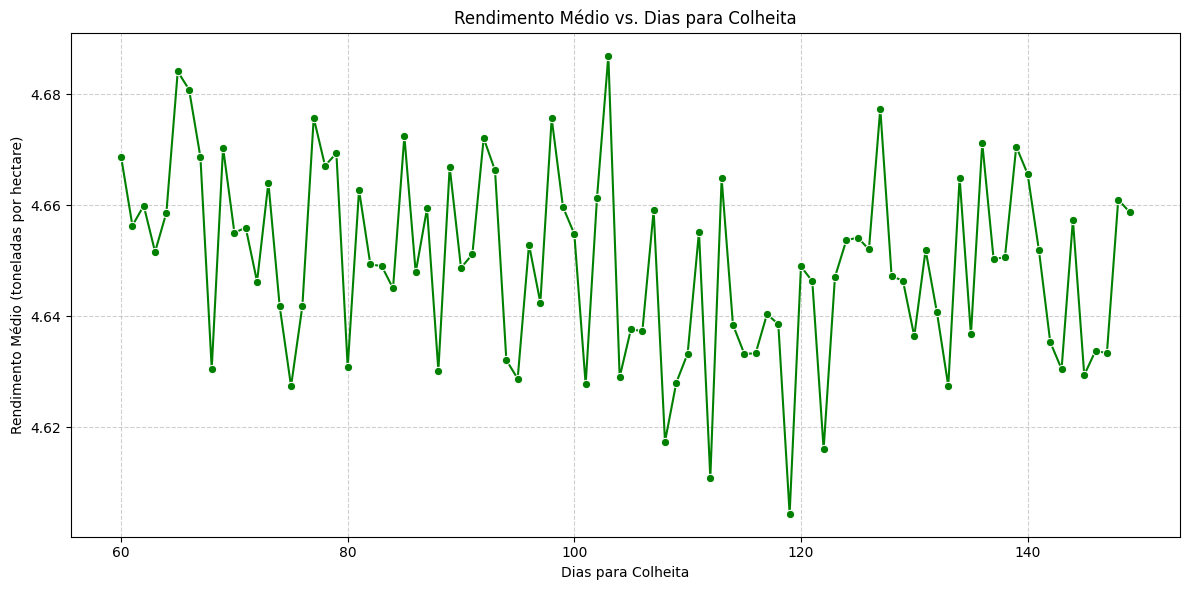

In [28]:
avg_yield_by_days = df.groupby('Days_to_Harvest')['Yield_tons_per_hectare'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Days_to_Harvest', y='Yield_tons_per_hectare', data=avg_yield_by_days, marker='o', color='green')
plt.title('Rendimento Médio vs. Dias para Colheita')
plt.xlabel('Dias para Colheita')
plt.ylabel('Rendimento Médio (toneladas por hectare)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 3. Histograma: Distribuição do Rendimento (Yield_tons_per_hectare)

O histograma mostra a distribuição da variável 'Yield_tons_per_hectare'. É interessante para entender a faixa de valores do rendimento, sua simetria e se há múltiplos picos (modas) que podem indicar diferentes regimes de produtividade.

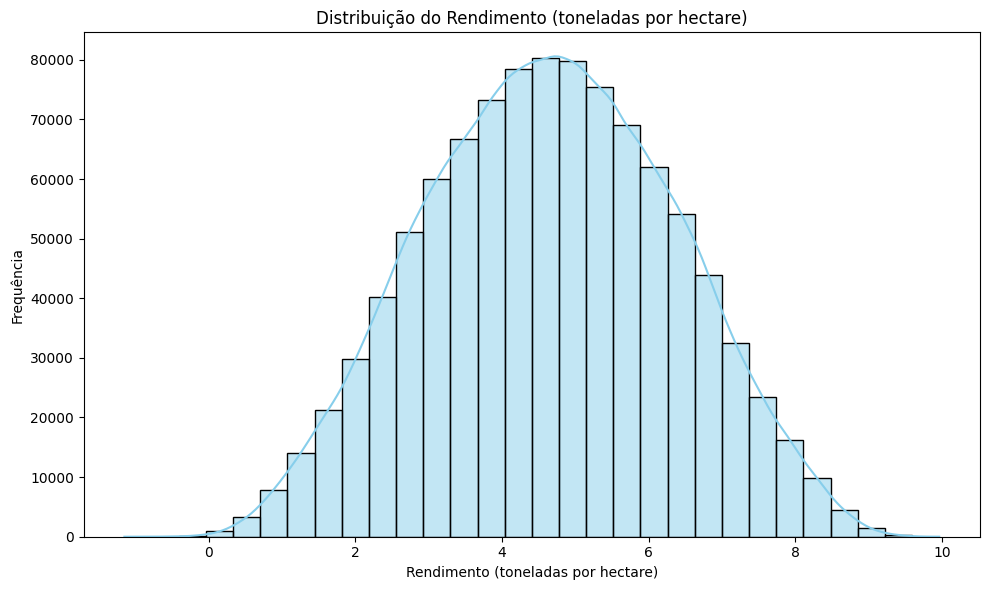

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Yield_tons_per_hectare'], kde=True, bins=30, color='skyblue')
plt.title('Distribuição do Rendimento (toneladas por hectare)')
plt.xlabel('Rendimento (toneladas por hectare)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

### 4. Scatter Plot (Dispersão): Chuva vs. Rendimento

Este gráfico de dispersão é excelente para visualizar a relação entre duas variáveis numéricas contínuas. Aqui, ele nos ajuda a investigar se há alguma correlação entre a quantidade de chuva ('Rainfall_mm') e o rendimento ('Yield_tons_per_hectare').

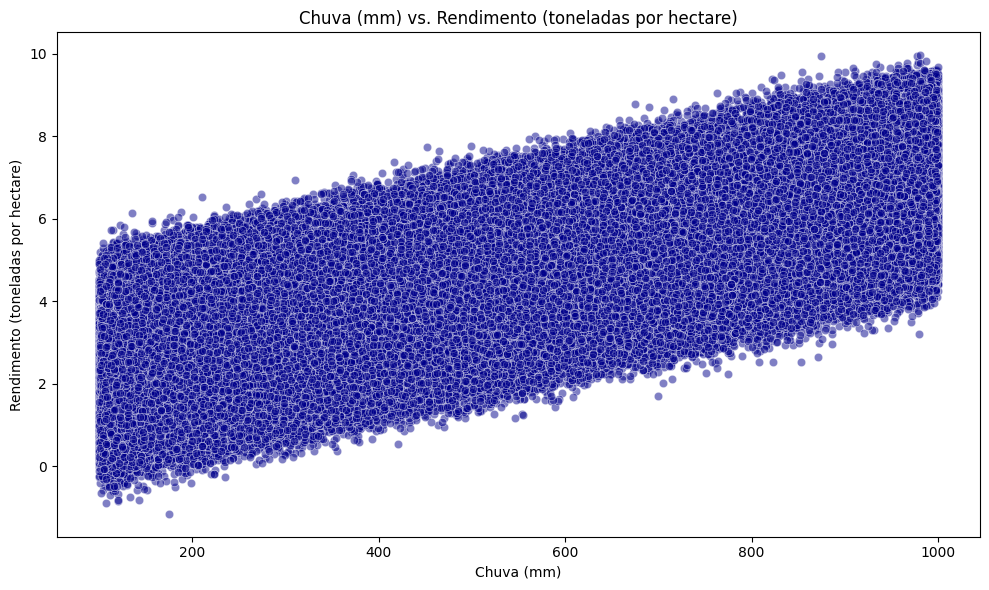

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rainfall_mm', y='Yield_tons_per_hectare', data=df, alpha=0.5, color='darkblue')
plt.title('Chuva (mm) vs. Rendimento (toneladas por hectare)')
plt.xlabel('Chuva (mm)')
plt.ylabel('Rendimento (toneladas por hectare)')
plt.tight_layout()
plt.show()

### 5. Heatmap (Mapa de Calor): Matriz de Correlação

Um heatmap da matriz de correlação nos permite ver rapidamente as relações lineares entre todas as variáveis numéricas do dataset. Valores próximos a 1 ou -1 indicam forte correlação positiva ou negativa, respectivamente, enquanto valores próximos a 0 indicam pouca ou nenhuma correlação. Isso é crucial para entender a interdependência dos fatores.

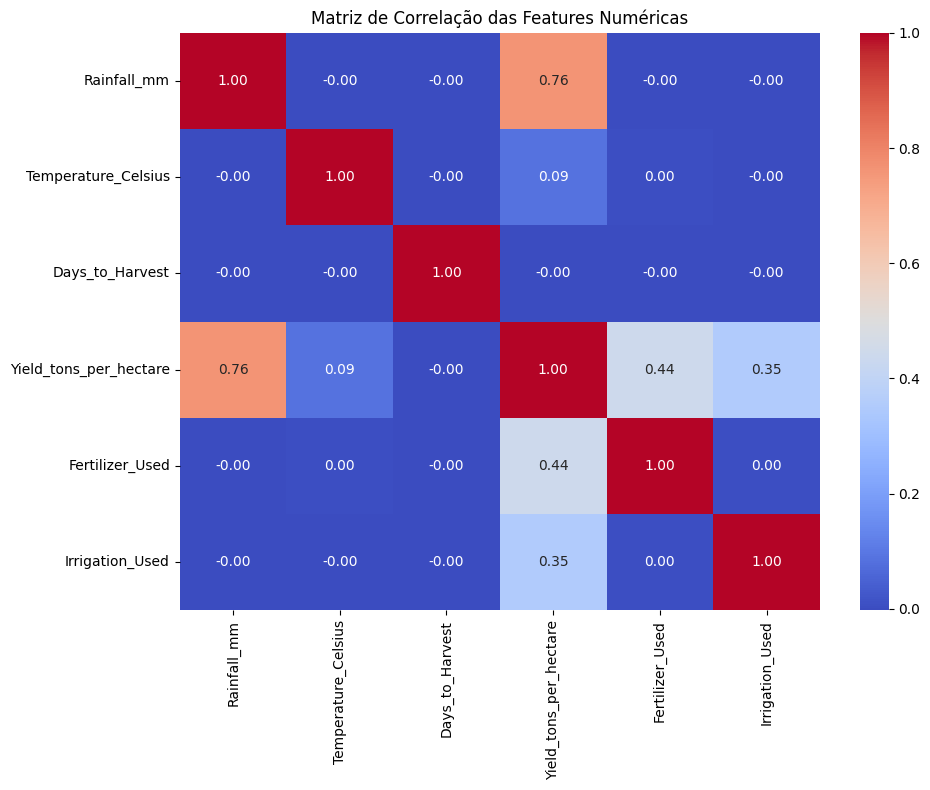

In [31]:
numerical_cols = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest', 'Yield_tons_per_hectare', 'Fertilizer_Used', 'Irrigation_Used']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Features Numéricas')
plt.tight_layout()
plt.show()

### 6. Boxplot: Distribuição do Rendimento por Tipo de Solo

O boxplot é ideal para comparar a distribuição de uma variável numérica (Yield_tons_per_hectare) entre diferentes categorias (Soil_Type). Ele mostra a mediana, quartis e possíveis outliers, ajudando a entender como o tipo de solo influencia o rendimento.

C:\Users\igorp\AppData\Local\Temp\ipykernel_15720\2724929569.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Soil_Type', y='Yield_tons_per_hectare', data=df, palette='pastel')


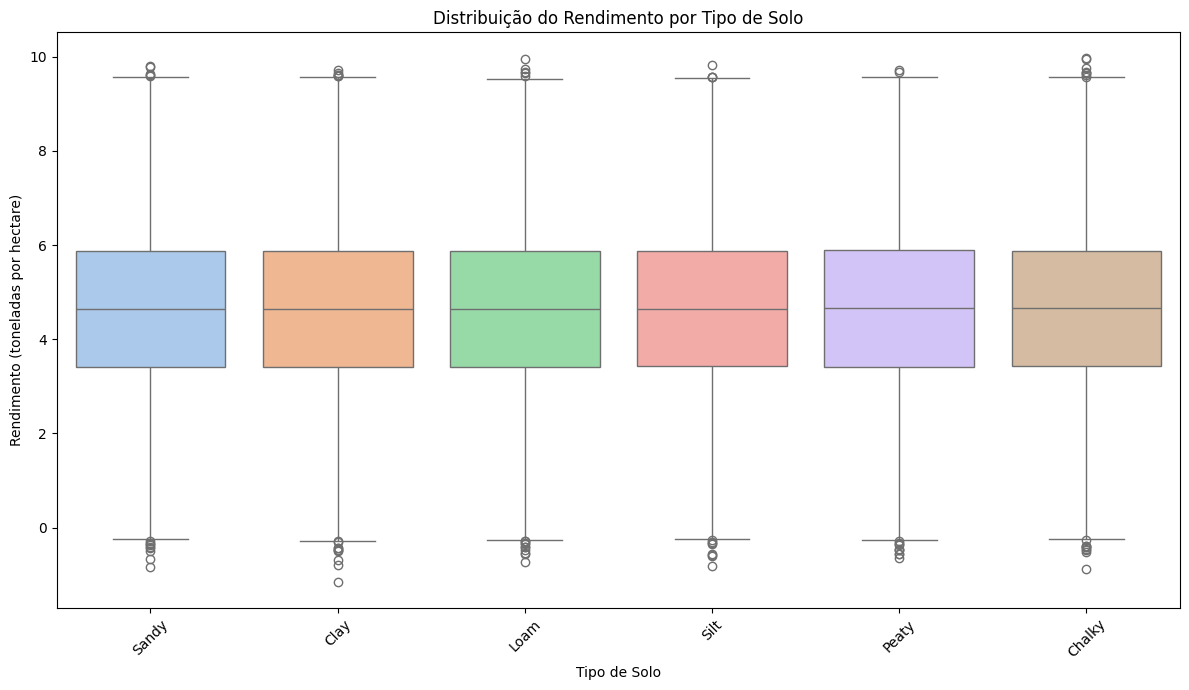

In [32]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Soil_Type', y='Yield_tons_per_hectare', data=df, palette='pastel')
plt.title('Distribuição do Rendimento por Tipo de Solo')
plt.xlabel('Tipo de Solo')
plt.ylabel('Rendimento (toneladas por hectare)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7. Radar Chart: Condições Climáticas Médias por Região

O Radar Chart (ou Gráfico de Teia) é excelente para comparar múltiplos atributos de diferentes entidades. Aqui, vamos agrupar a média de chuvas e temperatura por condição climática para ver como elas variam. Para este gráfico, vamos precisar de uma agregação específica.

In [33]:
avg_weather_conditions = df.groupby('Weather_Condition')[['Rainfall_mm', 'Temperature_Celsius', 'Yield_tons_per_hectare']].mean().reset_index()

categories = ['Rainfall_mm', 'Temperature_Celsius', 'Yield_tons_per_hectare']

fig = go.Figure()

for i, row in avg_weather_conditions.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[row['Rainfall_mm'], row['Temperature_Celsius'], row['Yield_tons_per_hectare']],
        theta=categories,
        fill='toself',
        name=row['Weather_Condition']
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, max(avg_weather_conditions[categories].max()) * 1.1]
        )
    ),
    showlegend=True,
    title='Condições Médias de Chuva, Temperatura e Rendimento por Condição Climática'
)

fig.show()

### 8. Área Acumulada (Area Chart): Contagem de Culturas ao longo dos Dias para Colheita

Um gráfico de área acumulada pode mostrar a proporção de diferentes categorias ao longo de um eixo contínuo. Como não temos um tempo explícito, podemos usar os 'Days_to_Harvest' e a contagem de 'Crop' para ver a distribuição cumulativa.

In [34]:
df_area = df.groupby(['Days_to_Harvest', 'Crop']).size().reset_index(name='Count')

fig = px.area(df_area, x='Days_to_Harvest', y='Count', color='Crop',
              title='Contagem de Culturas ao longo dos Dias para Colheita (Área Acumulada)')
fig.update_layout(yaxis_title='Número de Ocorrências')
fig.show()

### 9. Bubble Chart: Chuva, Temperatura e Rendimento por Tipo de Solo

O Bubble Chart (Gráfico de Bolhas) é uma ótima maneira de visualizar a relação entre três ou quatro variáveis numéricas. Aqui, usaremos 'Rainfall_mm' no eixo X, 'Temperature_Celsius' no eixo Y, 'Yield_tons_per_hectare' para o tamanho da bolha e 'Soil_Type' para a cor. Isso nos permite ver como esses fatores se combinam para influenciar o rendimento em diferentes tipos de solo.

In [35]:
fig = px.scatter(df.sample(n=5000, random_state=42), # Amostra para melhor visualização
                 x='Rainfall_mm',
                 y='Temperature_Celsius',
                 size='Yield_tons_per_hectare',
                 color='Soil_Type',
                 hover_name='Crop',
                 log_x=True,
                 size_max=60,
                 title='Chuva, Temperatura e Rendimento por Tipo de Solo (Bubble Chart)')
fig.show()

### 10. Treemap: Distribuição de Culturas por Região e Tipo de Solo

Um Treemap é uma visualização hierárquica que mostra a proporção de diferentes categorias. Aqui, vamos visualizar a distribuição das 'Crop' dentro de cada 'Region' e 'Soil_Type', permitindo identificar rapidamente as combinações mais predominantes.

In [36]:
import squarify

df_treemap = df.groupby(['Region', 'Soil_Type', 'Crop']).size().reset_index(name='Count')
df_treemap['path'] = df_treemap['Region'] + " - " + df_treemap['Soil_Type'] + " - " + df_treemap['Crop']

fig = px.treemap(df_treemap, path=[px.Constant("all"), 'Region', 'Soil_Type', 'Crop'], values='Count',
                 title='Distribuição Hierárquica de Culturas por Região e Tipo de Solo')
fig.show()

#Treino



### Preparação dos Dados para Treinamento

Vamos definir as features (variáveis de entrada) e o target (variável de saída). As variáveis categóricas ('Region', 'Soil_Type', 'Crop', 'Weather_Condition') precisam ser convertidas em formato numérico usando One-Hot Encoding. Em seguida, dividiremos o dataset em conjuntos de treino e teste.

In [37]:
from sklearn.model_selection import train_test_split

# Definindo features (X) e target (y)
X = df.drop('Yield_tons_per_hectare', axis=1)
y = df['Yield_tons_per_hectare']

# Identificando colunas categóricas e numéricas
categorical_features = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

Shape de X_train: (800000, 9)
Shape de X_test: (200000, 9)
Shape de y_train: (800000,)
Shape de y_test: (200000,)


In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline de pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Pipeline de pré-processamento criado.")

Pipeline de pré-processamento criado.


## MODELING

### Modelo 1: Regressão Linear

Começaremos com um modelo de regressão linear como baseline. É um modelo simples que tenta encontrar uma relação linear entre as features e o target.

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Inicializar e treinar o modelo
model_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

model_lr.fit(X_train, y_train)

# Fazer previsões
y_pred_lr = model_lr.predict(X_test)

# Avaliar o modelo
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Avaliação do Modelo de Regressão Linear ---")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.4f}")
print(f"R-squared (R2): {r2_lr:.4f}")

--- Avaliação do Modelo de Regressão Linear ---
Mean Absolute Error (MAE): 0.3996
Mean Squared Error (MSE): 0.2508
Root Mean Squared Error (RMSE): 0.5008
R-squared (R2): 0.9130


### Modelo 2: Decision Tree Regressor

O Decision Tree é um modelo mais rápido de treinar do que o Random Forest e pode servir como uma boa alternativa para comparação, especialmente quando o tempo de treinamento é uma preocupação.

In [40]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
import numpy as np

# Inicializar e treinar o modelo
model_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

model_dt.fit(X_train, y_train)

# Fazer previsões
y_pred_dt = model_dt.predict(X_test)

# Avaliar o modelo
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("--- Avaliação do Modelo Decision Tree Regressor ---")
print(f"Mean Absolute Error (MAE): {mae_dt:.4f}")
print(f"Mean Squared Error (MSE): {mse_dt:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.4f}")
print(f"R-squared (R2): {r2_dt:.4f}")

--- Avaliação do Modelo Decision Tree Regressor ---
Mean Absolute Error (MAE): 0.5838
Mean Squared Error (MSE): 0.5335
Root Mean Squared Error (RMSE): 0.7304
R-squared (R2): 0.8149


### Modelo 3: Gradient Boosting Regressor

Gradient Boosting é outro poderoso algoritmo de ensemble que constrói modelos de forma sequencial, onde cada novo modelo tenta corrigir os erros do anterior.

In [41]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
import numpy as np

# Inicializar e treinar o modelo
model_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

model_gb.fit(X_train, y_train)

# Fazer previsões
y_pred_gb = model_gb.predict(X_test)

# Avaliar o modelo
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("--- Avaliação do Modelo Gradient Boosting Regressor ---")
print(f"Mean Absolute Error (MAE): {mae_gb:.4f}")
print(f"Mean Squared Error (MSE): {mse_gb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gb:.4f}")
print(f"R-squared (R2): {r2_gb:.4f}")

--- Avaliação do Modelo Gradient Boosting Regressor ---
Mean Absolute Error (MAE): 0.4009
Mean Squared Error (MSE): 0.2524
Root Mean Squared Error (RMSE): 0.5024
R-squared (R2): 0.9125


## EVALUATION - AVALIAÇÃO DO MODELO

### Comparação dos Modelos e Salvamento do Melhor

Agora vamos comparar as métricas de desempenho de todos os modelos e salvar o modelo com o melhor R-squared (R2) usando `joblib`.

In [42]:
import joblib

results = {
    'Linear Regression': {'MAE': mae_lr, 'MSE': mse_lr, 'RMSE': rmse_lr, 'R2': r2_lr, 'Model': model_lr},
    'Decision Tree': {'MAE': mae_dt, 'MSE': mse_dt, 'RMSE': rmse_dt, 'R2': r2_dt, 'Model': model_dt},
    'Gradient Boosting': {'MAE': mae_gb, 'MSE': mse_gb, 'RMSE': rmse_gb, 'R2': r2_gb, 'Model': model_gb}
}

print("\n--- Sumário de Desempenho dos Modelos ---")
for name, metrics in results.items():
    print(f"\nModelo: {name}")
    print(f"  MAE: {metrics['MAE']:.4f}")
    print(f"  MSE: {metrics['MSE']:.4f}")
    print(f"  RMSE: {metrics['RMSE']:.4f}")
    print(f"  R2: {metrics['R2']:.4f}")

# Encontrar o melhor modelo com base no R2
best_model_name = max(results, key=lambda k: results[k]['R2'])
best_model_info = results[best_model_name]
best_model = best_model_info['Model']

print(f"\nO melhor modelo com base no R2 é: {best_model_name} (R2: {best_model_info['R2']:.4f})")

# Salvar o melhor modelo usando joblib
joblib_filename = 'best_yield_prediction_model.joblib'
joblib.dump(best_model, joblib_filename)
print(f"Modelo '{best_model_name}' salvo como '{joblib_filename}'")


--- Sumário de Desempenho dos Modelos ---

Modelo: Linear Regression
  MAE: 0.3996
  MSE: 0.2508
  RMSE: 0.5008
  R2: 0.9130

Modelo: Decision Tree
  MAE: 0.5838
  MSE: 0.5335
  RMSE: 0.7304
  R2: 0.8149

Modelo: Gradient Boosting
  MAE: 0.4009
  MSE: 0.2524
  RMSE: 0.5024
  R2: 0.9125

O melhor modelo com base no R2 é: Linear Regression (R2: 0.9130)
Modelo 'Linear Regression' salvo como 'best_yield_prediction_model.joblib'


### Testando o Modelo Salvo

Vamos carregar o modelo salvo e fazer previsões no conjunto de teste (`X_test`) para confirmar que ele está funcionando corretamente e que as métricas de desempenho são consistentes com as que obtivemos durante o treinamento.

In [43]:
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Carregar o modelo salvo
joblib_filename = 'best_yield_prediction_model.joblib'
loaded_model = joblib.load(joblib_filename)

print(f"Modelo carregado: {type(loaded_model).__name__}")

# Fazer previsões com o modelo carregado
y_pred_loaded = loaded_model.predict(X_test)

# Avaliar o modelo carregado
mae_loaded = mean_absolute_error(y_test, y_pred_loaded)
mse_loaded = mean_squared_error(y_test, y_pred_loaded)
rmse_loaded = np.sqrt(mse_loaded)
r2_loaded = r2_score(y_test, y_pred_loaded)

print("\n--- Avaliação do Modelo Carregado ---")
print(f"Mean Absolute Error (MAE): {mae_loaded:.4f}")
print(f"Mean Squared Error (MSE): {mse_loaded:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_loaded:.4f}")
print(f"R-squared (R2): {r2_loaded:.4f}")

if np.isclose(r2_loaded, best_model_info['R2']):
    print("\nO R2 do modelo carregado é consistente com o do melhor modelo treinado. O modelo foi salvo corretamente!")
else:
    print("\nAtenção: O R2 do modelo carregado difere do melhor modelo treinado. Pode haver um problema no salvamento/carregamento.")

Modelo carregado: Pipeline

--- Avaliação do Modelo Carregado ---
Mean Absolute Error (MAE): 0.3996
Mean Squared Error (MSE): 0.2508
Root Mean Squared Error (RMSE): 0.5008
R-squared (R2): 0.9130

O R2 do modelo carregado é consistente com o do melhor modelo treinado. O modelo foi salvo corretamente!


### Criando um "Modelo de Teste" para Novas Previsões

Agora que confirmamos que o modelo salvo está funcionando corretamente, vamos criar uma maneira fácil de usá-lo para fazer previsões em novos dados. A função `predict_yield` abaixo aceitará um dicionário com as características de uma nova colheita, fará o pré-processamento necessário e retornará a previsão de rendimento.

In [44]:
def predict_yield(new_data_raw, model):
    """
    Faz a previsão utilizando o pipeline treinado.
    """

    new_data_df = pd.DataFrame([new_data_raw])

    prediction = model.predict(new_data_df)

    return prediction[0]


# Exemplo de uso
new_sample = {
    'Region': 'East',
    'Soil_Type': 'Chalky',
    'Crop': 'Maize',
    'Rainfall_mm': 750.0,
    'Temperature_Celsius': 28.5,
    'Fertilizer_Used': 1,
    'Irrigation_Used': 0,
    'Weather_Condition': 'Cloudy',
    'Days_to_Harvest': 100
}

predicted_yield_new = predict_yield(
    new_sample,
    loaded_model
)

print(
    f"\nPrevisão de rendimento para os novos dados: "
    f"{predicted_yield_new:.2f} toneladas por hectare"
)


Previsão de rendimento para os novos dados: 5.82 toneladas por hectare
